# DiaModel

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import sys

# configure logging
logging.basicConfig(force=True, stream=sys.stdout, level=logging.DEBUG)
h = logging.root.handlers[0]
modules = ["hive", "cmdstanpy"]
h.addFilter(lambda record: any(map(record.name.startswith, modules)))

In [3]:
# Enable chart rendering on github
import altair as alt
alt.renderers.enable("svg")

RendererRegistry.enable('svg')

## Prepare Data

In [4]:
import pandas as pd

import diamodel as dm

In [5]:
cfg = dm.Config.default_config()
cfg

Config(name='default', dt=5, maxact=108, maxpred=48, gscale=0.16666666666666666, nsamples=500)

In [6]:
def load_data(csv_path, cfg):
    """Loads csv and assigns ticks"""
    data_df = pd.read_csv(csv_path, parse_dates=["timestamp"])
    assert len(data_df) > 0

    t0 = data_df.iloc[0].timestamp

    def ts_to_tick(ts):
        secs = (ts - t0).total_seconds()
        return round(secs / 60 / cfg.dt)

    # assign ticks as discretized timestamps
    data_df["tick"] = data_df["timestamp"].map(ts_to_tick)
    data_df.set_index("tick", drop=False, inplace=True)
    return data_df

In [7]:
data_df = load_data("../data/child1.csv", cfg)
data_df.shape

(7630, 5)

In [8]:
data_df.head()

,timestamp,cgm,carbs,insulin,tick
tick,,,,,
0,2025-10-23 09:04:00,7.7,NaN,NaN,0
1,2025-10-23 09:09:00,7.5,NaN,NaN,1
2,2025-10-23 09:14:00,6.0,NaN,NaN,2
3,2025-10-23 09:19:00,6.1,NaN,NaN,3
4,2025-10-23 09:24:00,6.1,NaN,NaN,4


In [9]:
# show daily stats
data_df["date"] = data_df["timestamp"].dt.date
intervals_df = data_df.groupby("date")[["cgm", "carbs", "insulin"]].count()
intervals_df

,cgm,carbs,insulin
date,,,
2025-10-23,180,11,11
2025-10-24,288,19,18
2025-10-25,288,22,21
2025-10-26,287,11,11
2025-10-27,288,23,23
2025-10-28,288,15,14
2025-10-29,288,20,19
2025-10-30,288,15,15
2025-10-31,275,19,19


## Fit Models

In [10]:
from collections import namedtuple

import charts
import seaborn as sns

### Fit Insulin-only Model

Select insulin-only intervals to estimate insulin params:
 * `isens` - insulin sensitivity
 * `ipeak` - insulin absorption "peak"


In [11]:
imodel = dm.InsulinModel(cfg)
ichunks = imodel.select_chunks(data_df)
ichunks.shape

(19,)

In [12]:
# prior
ifit0 = dm.Fit.default(cfg)
ifit0

Fit(isens=4.979 ipeak=3.004 rho=0.897 sigma=1.002 csens=0.301 cpeak=4.031 carbs=0 insulin=0 cpeaki=None ccorri=None chunks=None bg0i=None lp__=None fit_at=None)

In [13]:
ifit = imodel.fit(data_df, prior_fit=ifit0, chunks=ichunks)

DEBUG:cmdstanpy:found newer exe file, not recompiling
DEBUG:cmdstanpy:cmd: /home/diamodel/diamodel/diamodel/stan/model_insulin info
cwd: None
DEBUG:cmdstanpy:input tempfile: /tmp/tmpo25g8amo/6c93nh1_.json
INFO:cmdstanpy:CmdStan start processing
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:CmdStan args: ['/home/diamodel/diamodel/diamodel/stan/model_insulin', 'id=1', 'random', 'seed=42', 'data', 'file=/tmp/tmpo25g8amo/6c93nh1_.json', 'output', 'file=/tmp/tmpo25g8amo/model_insulinfn3rkg5c/model_insulin-20251224175644_1.csv', 'method=sample', 'num_samples=2000', 'algorithm=hmc', 'adapt', 'engaged=1']
DEBUG:cmdstanpy:idx 2
DEBUG:cmdstanpy:idx 1
DEBUG:cmdstanpy:idx 3
INFO:cmdstanpy:Chain [1] start processing
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:CmdStan args: ['/home/diamodel/diamodel/diamodel/stan/model_insulin', 'id=3', 'random',

In [14]:
ifit

Fit(isens=6.148 ipeak=2.186 rho=0.98 sigma=0.996 csens=0.301 cpeak=4.031 carbs=0 insulin=92 cpeaki=None ccorri=None chunks=19 bg0i=7.099 lp__=270.864 fit_at=None)

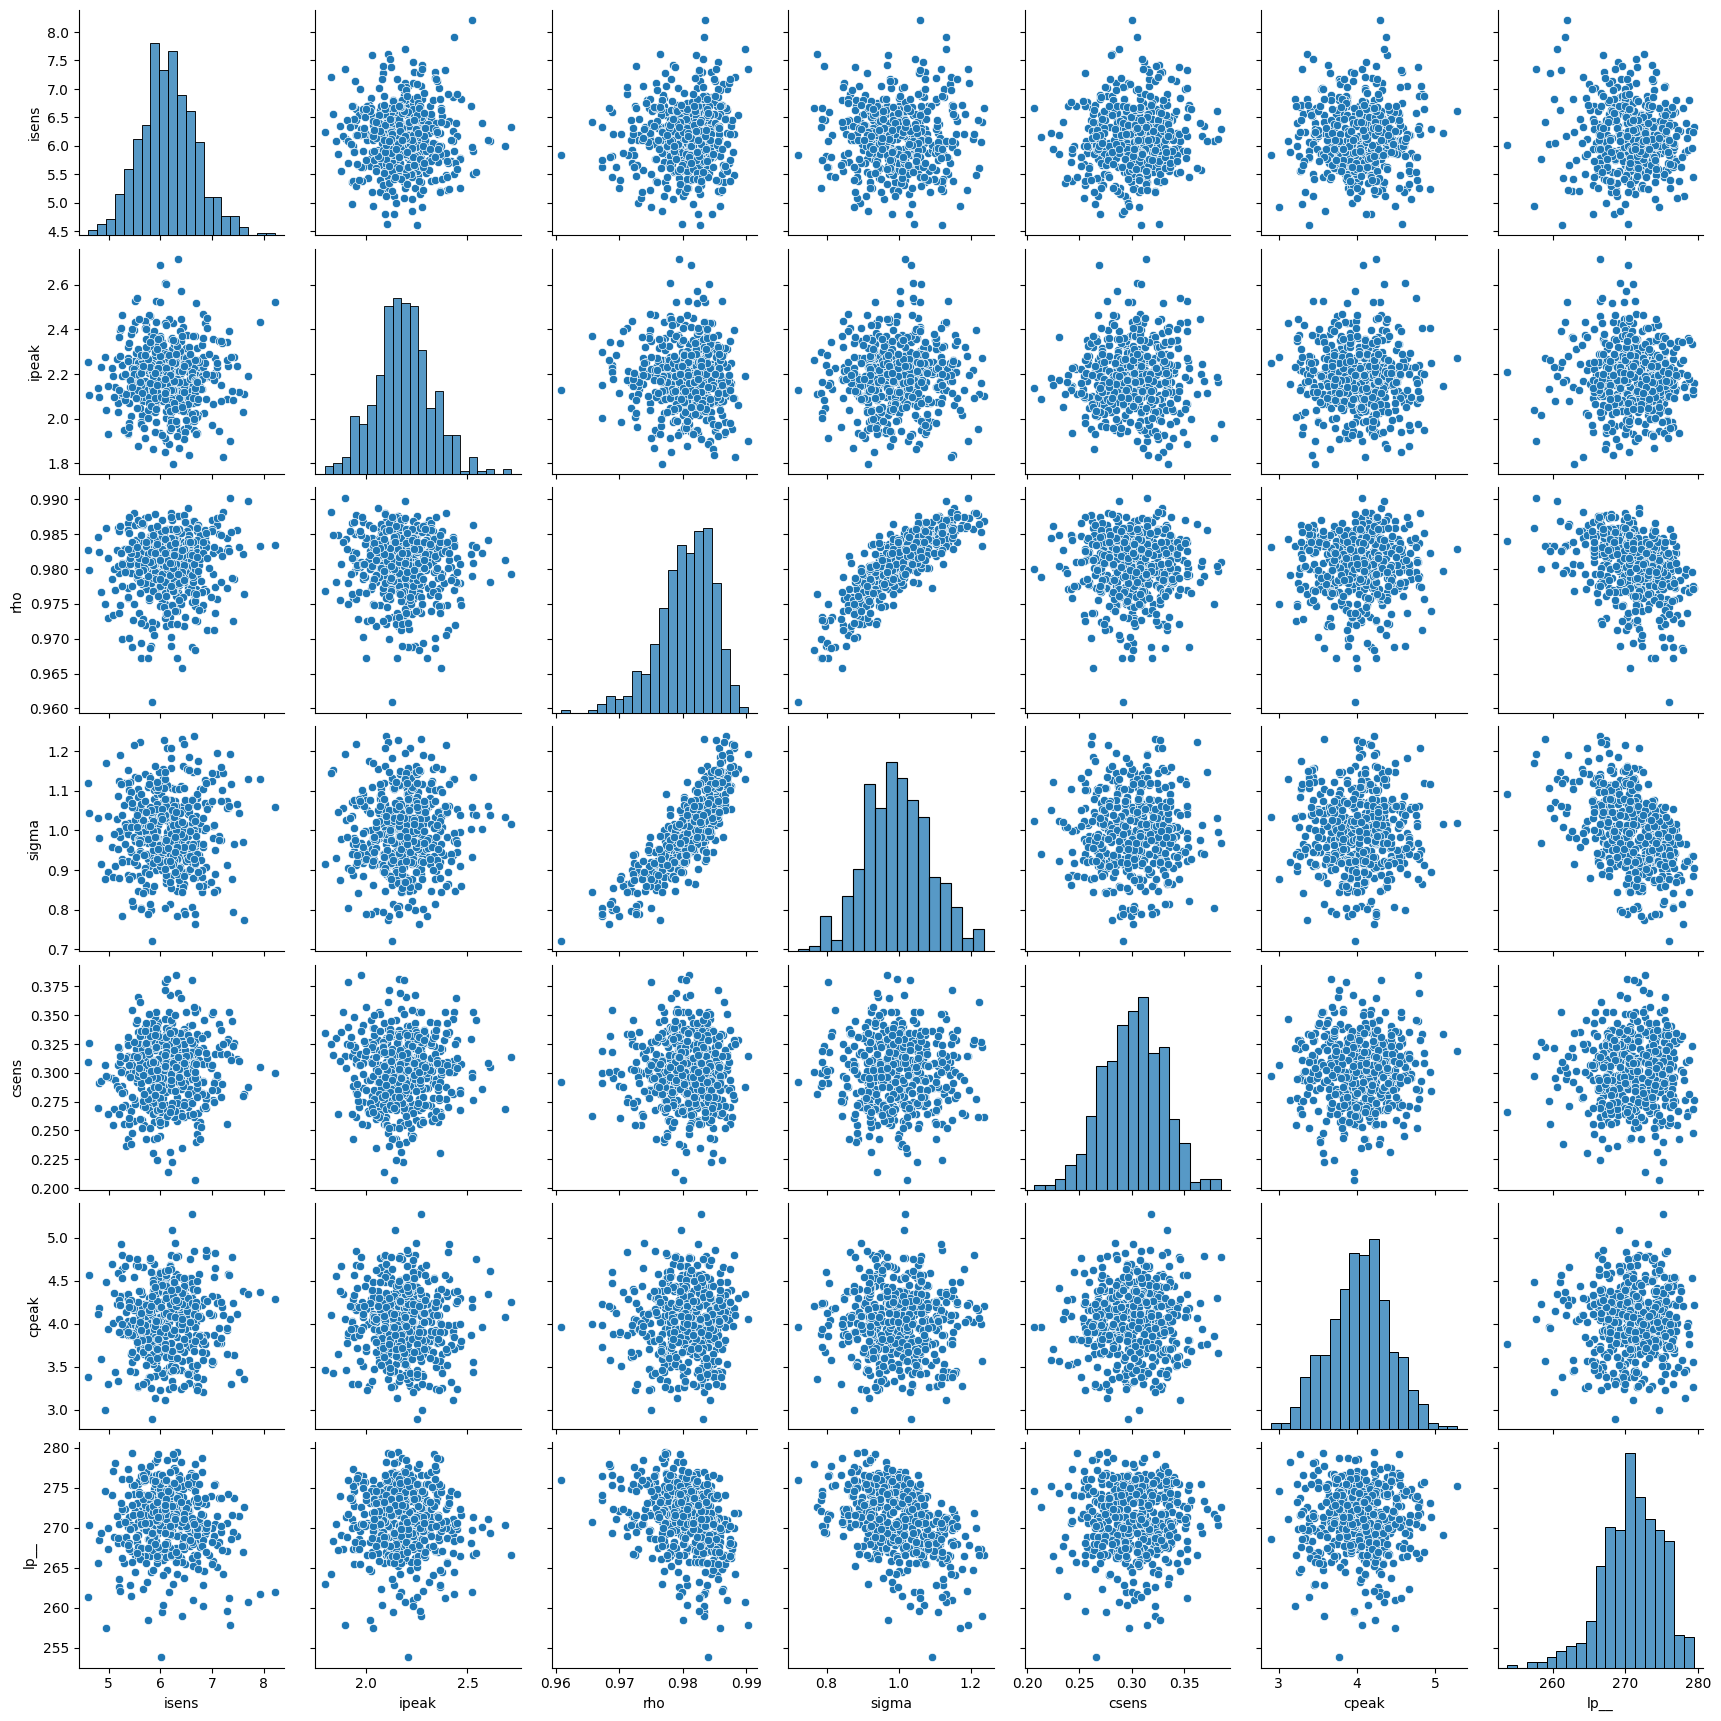

In [15]:
# csens and cpeak values are not estimated and taken from the prior.
# Visualize full posterior for insulin-only model
sns.pairplot(ifit.to_df())

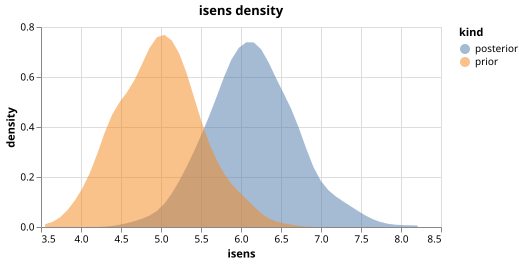

In [16]:
# plot isens (CF) posterior
charts.plot_density("isens", ifit, prior=ifit0)

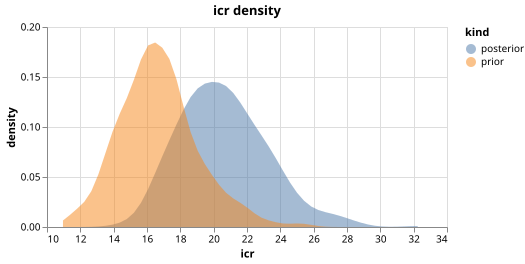

In [17]:
# plot ICR posterior
charts.plot_density("icr", ifit, prior=ifit0)

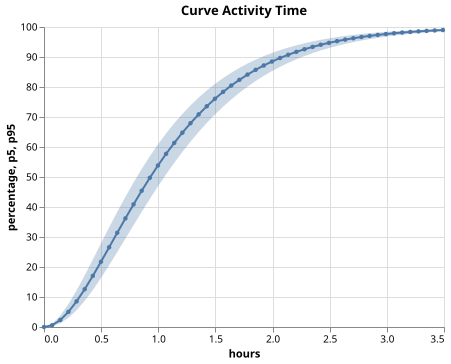

In [18]:
# visualize insulin activity time
charts.plot_curve_cdf(ifit.ipeak, cfg)

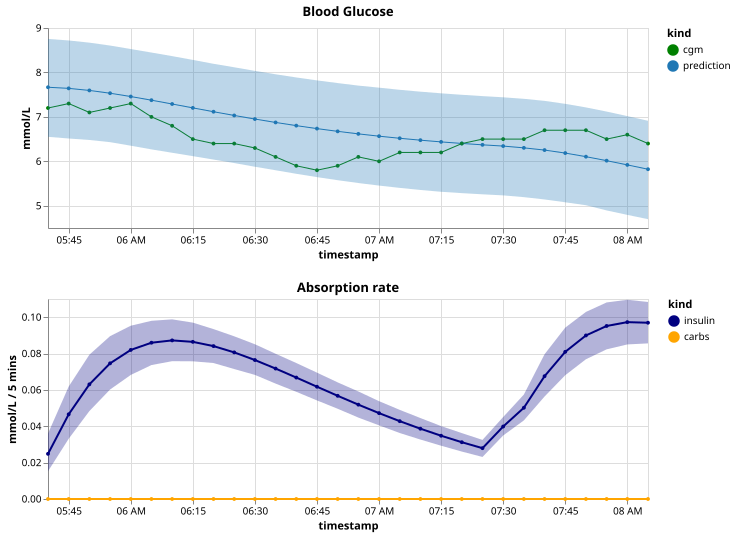

In [19]:
# Visualize predictions in each training chunk
a, s = list(ifit.chunks.items())[2]
ticka = a
tickb = a + s
charts.plot_predictions(ticka, tickb, data_df, ifit, cfg)

### Fit full model

Here we perform joint estimation of carbs and insulin params

In [20]:
def scale_std(arr, target_std):
    mean = arr.mean()
    std = arr.std()

    # Center, scale, then shift back
    scaled = (arr - mean) * (target_std / std) + mean
    return scaled

In [21]:
# use insulin-only fit as a prior for the full model
fit0 = ifit.copy()
fit0.isens = scale_std(fit0.isens, 0.1)  # set informative (narrow) prior
fit0

Fit(isens=6.148 ipeak=2.186 rho=0.98 sigma=0.996 csens=0.301 cpeak=4.031 carbs=0 insulin=92 cpeaki=None ccorri=None chunks=19 bg0i=7.099 lp__=270.864 fit_at=None)

In [22]:
# Fitting full model may take over an hour. Here we take a subset of data (last N days) to speed up training.
data_small_df = data_df[data_df["date"].isin(intervals_df[-5:].index)]
data_small_df.shape

(1403, 6)

In [23]:
# select training intervals
model = dm.DiaModel(cfg)
chunks = model.select_chunks(data_small_df)
chunks.shape

(27,)

In [24]:
fit_full = model.fit(data_small_df, prior_fit=fit0, chunks=chunks)

DEBUG:cmdstanpy:found newer exe file, not recompiling
DEBUG:cmdstanpy:cmd: /home/diamodel/diamodel/diamodel/stan/model_full info
cwd: None
DEBUG:cmdstanpy:input tempfile: /tmp/tmpo25g8amo/9889vqhb.json
INFO:cmdstanpy:CmdStan start processing
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:CmdStan args: ['/home/diamodel/diamodel/diamodel/stan/model_full', 'id=1', 'random', 'seed=42', 'data', 'file=/tmp/tmpo25g8amo/9889vqhb.json', 'output', 'file=/tmp/tmpo25g8amo/model_fulli1mky3ll/model_full-20251224175716_1.csv', 'method=sample', 'num_samples=2000', 'algorithm=hmc', 'adapt', 'engaged=1']
DEBUG:cmdstanpy:idx 1
DEBUG:cmdstanpy:idx 3
DEBUG:cmdstanpy:idx 2
INFO:cmdstanpy:Chain [1] start processing
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:CmdStan args: ['/home/diamodel/diamodel/diamodel/stan/model_full', 'id=2', 'random', 'seed=42', 'da

In [25]:
fit_full

Fit(isens=6.161 ipeak=2.653 rho=0.986 sigma=1.421 csens=0.388 cpeak=3.118 carbs=47 insulin=78 cpeaki=2.997 ccorri=0.251 chunks=27 bg0i=7.789 lp__=759.667 fit_at=None)

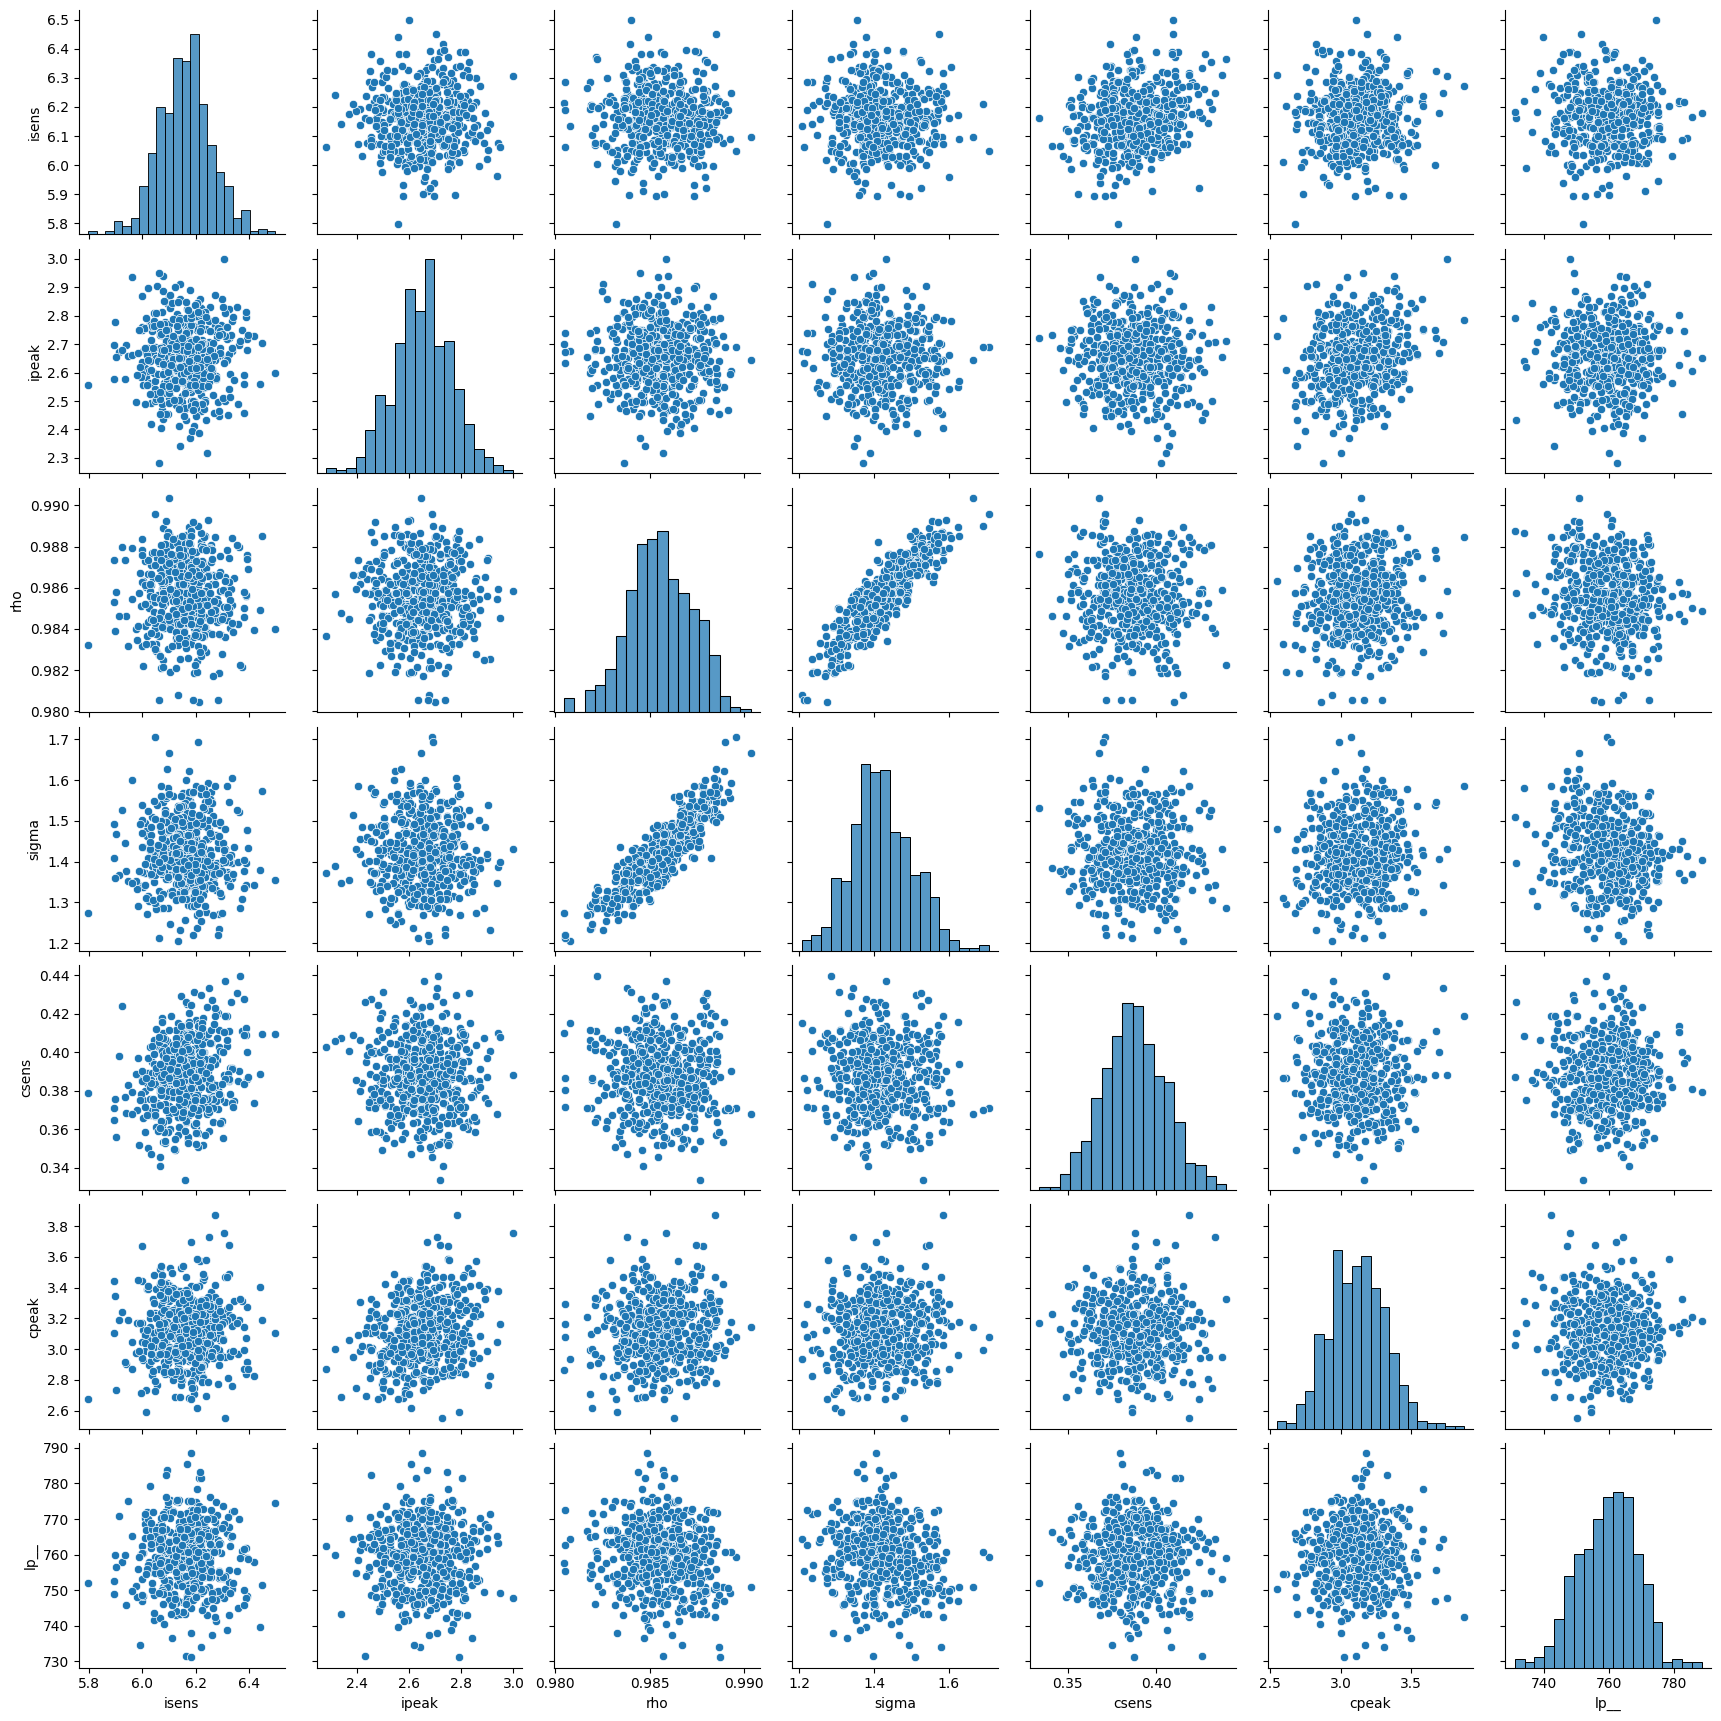

In [26]:
# Visualize full posterior for the full model
sns.pairplot(fit_full.to_df())

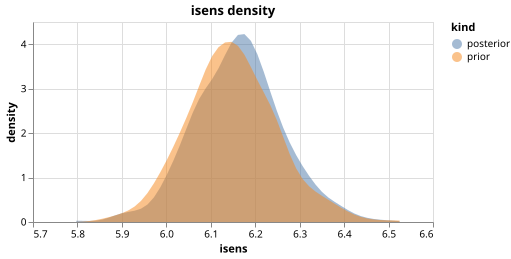

In [27]:
# plot isens (CF) posterior
charts.plot_density("isens", fit_full, prior=fit0)

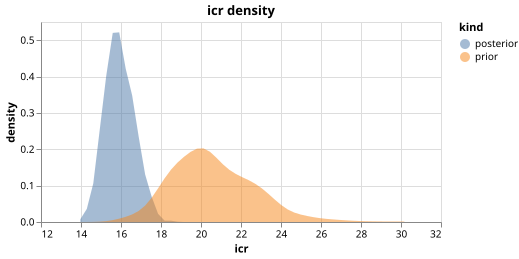

In [28]:
# plot isens (CF) posterior
charts.plot_density("icr", fit_full, prior=fit0)

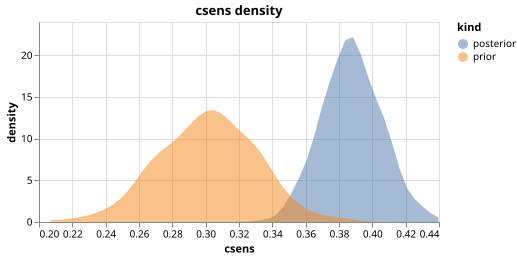

In [29]:
# plot csens posterior
charts.plot_density("csens", fit_full, prior=fit0)

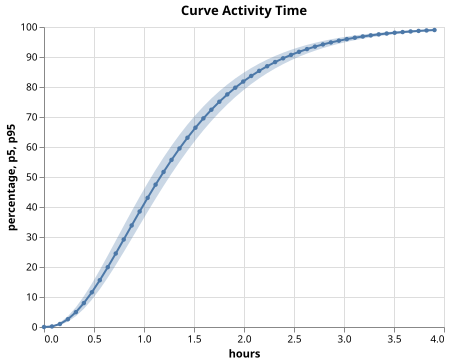

In [30]:
# visualize insulin activity time
charts.plot_curve_cdf(fit_full.ipeak, cfg)

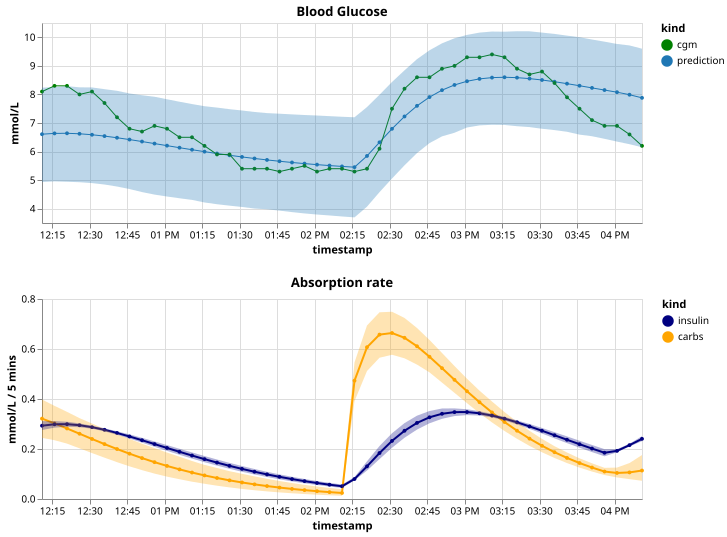

In [33]:
# visualize predictions in each training chunk
a, s = list(fit_full.chunks.items())[24]
ticka = a
tickb = a + s
charts.plot_predictions(ticka, tickb, data_df, fit_full, cfg)

### Fit full model incrementally

This allows tracking changes in parameters over time, which can help answer questions such as "when does the honeymoon period end?"

In [34]:
# perform incremental training to keep "local" params manageable
IntervalFit = namedtuple("IntervalFit", ["date", "data", "prior", "posterior"])

fits = []
model = dm.DiaModel(cfg)

# select last N intervals to speed up training
for date in intervals_df.index[-5:]:
    data = data_df[data_df["date"] == date]
    try:
        fit = model.fit(data, prior_fit=fit0)
    except Exception as e:
        print(f"Failed to fit date={date} err={e}")
        continue

    fits.append(IntervalFit(date, data, fit0, fit))
    fit0 = fit

len(fits)

DEBUG:cmdstanpy:found newer exe file, not recompiling
DEBUG:cmdstanpy:cmd: /home/diamodel/diamodel/diamodel/stan/model_full info
cwd: None
DEBUG:cmdstanpy:input tempfile: /tmp/tmpo25g8amo/ofbm32qb.json
INFO:cmdstanpy:CmdStan start processing
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:CmdStan args: ['/home/diamodel/diamodel/diamodel/stan/model_full', 'id=1', 'random', 'seed=42', 'data', 'file=/tmp/tmpo25g8amo/ofbm32qb.json', 'output', 'file=/tmp/tmpo25g8amo/model_fullhlgphcyi/model_full-20251224181326_1.csv', 'method=sample', 'num_samples=2000', 'algorithm=hmc', 'adapt', 'engaged=1']
INFO:cmdstanpy:Chain [1] start processing
DEBUG:cmdstanpy:idx 2
DEBUG:cmdstanpy:idx 1
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:idx 3
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:CmdStan args: ['/home/diamodel/diamodel/diamodel/stan/model_full', 'id=3', 'random', 'seed=42', 'data', 'file=/tmp/tmpo25g8amo/ofbm32qb.json', 'out

5

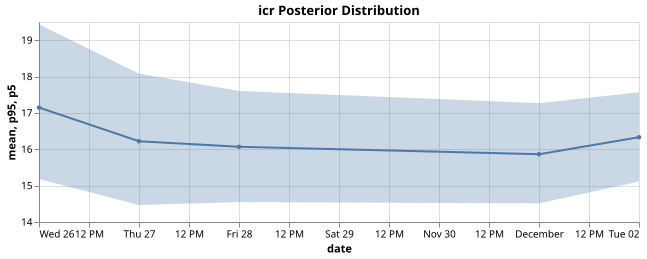

In [35]:
# visualize ICR posterior evolution over each interval
charts.plot_fits_density("icr", fits)

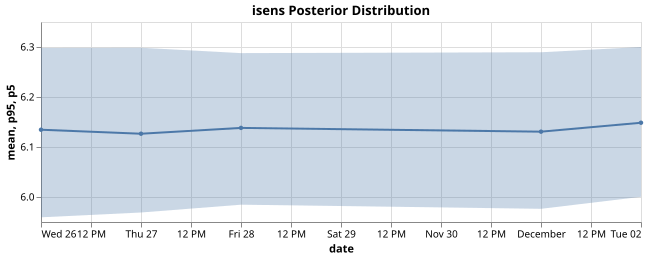

In [36]:
# visualize isens (CF) posterior evolution over each interval
charts.plot_fits_density("isens", fits)

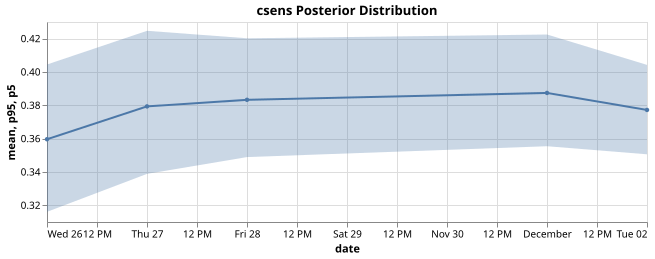

In [37]:
# visualize csens posterior evolution over each interval
charts.plot_fits_density("csens", fits)